In [1]:
import torch

from pytorch3d.structures import Volumes
from pytorch3d.renderer import (
FoVPerspectiveCameras, VolumeRenderer,
NDCGridRaysampler, EmissionAbsorptionRaymarcher,
look_at_view_transform
)

In [2]:
render_size = 256
volume_extent_world = 3.0
voxel_size = volume_extent_world / render_size
raysampler = NDCGridRaysampler(
    image_width = render_size,
    image_height = render_size,
    n_pts_per_ray = 150,
    min_depth = 0.1,
    max_depth = volume_extent_world,
)

raymarcher = EmissionAbsorptionRaymarcher()
renderer = VolumeRenderer(
    raysampler=raysampler,
    raymarcher=raymarcher,
)

In [3]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
device

'cuda:0'

In [4]:
densities = torch.load("/home/student/work/3d_Generative/model/dataset/dataset/table/test/table_0481/table_0481_d.pt", map_location=torch.device("cpu"), weights_only=True)
colors = torch.load("/home/student/work/3d_Generative/model/dataset/dataset/table/test/table_0481/table_0481_rgb.pt", map_location=torch.device("cpu"), weights_only=True)

In [5]:
x, y, z = 128, 128, 250
densities[..., x, y, z]

tensor([0.0003])

In [6]:
batch_size = 40
volumes = Volumes(
    densities = densities.unsqueeze(0).expand(
        batch_size, *densities.shape
    ),
    features = colors.unsqueeze(0).expand(
        batch_size, *colors.shape
    ),
    voxel_size = voxel_size
)
volumes = volumes.to(device)

In [7]:
elev_level = 2.7
azimuth_range = 180.0
num_views = 40
elev = torch.linspace(0, 0, num_views)  # keep constant
azim = torch.linspace(-azimuth_range, azimuth_range, num_views) + 180.0

R, T = look_at_view_transform(dist=2.7, elev=elev, azim=azim)
cameras = FoVPerspectiveCameras(device=device, R=R, T=T)
cameras = cameras.to(device)

rendered_images, rendered_silhouttes = renderer(cameras=cameras, volumes=volumes)[0].split([3, 1], dim = -1)
rendered_images = rendered_images.detach().cpu().numpy()
rendered_silhouttes = rendered_silhouttes.detach().cpu().numpy()

torch.cuda.empty_cache()

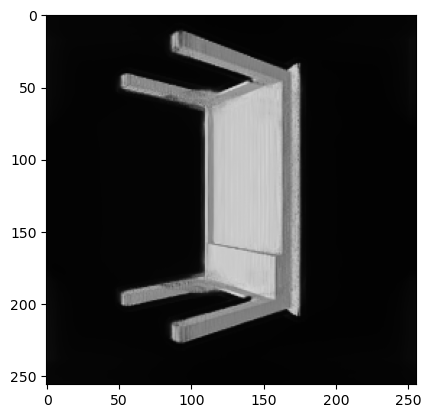

In [20]:
import matplotlib.pyplot as plt
plt.imshow(rendered_images[25])